--- Initializing Gym Membership Dataset for ID: 24142631 ---


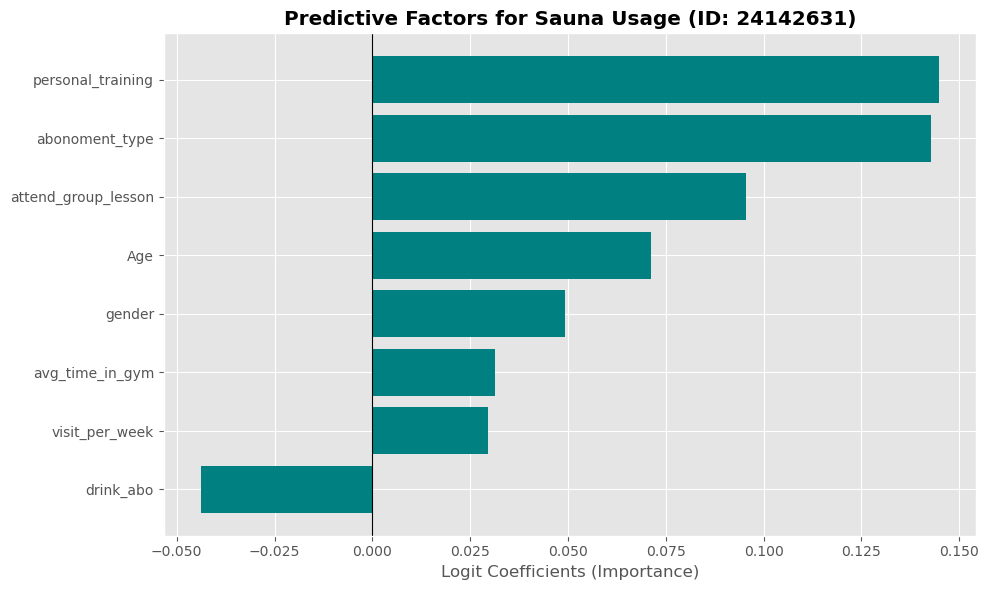

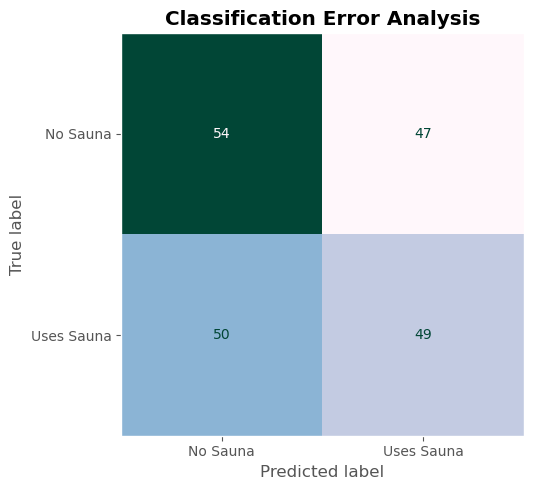

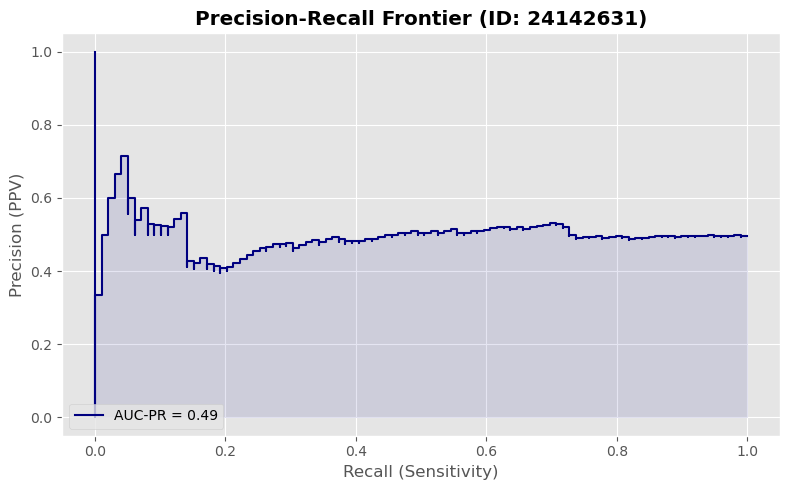


---
### 📊 Project Insights (ID: 24142631)
Github: https://github.com/bashueng-hash/Gym-membership
* **Primary Metric:** Precision-Recall AUC achieved: **0.49**.
* **Key Finding:** 'Abonoment_type' and 'Personal_training' are the strongest indicators of sauna usage.
* **Optimization:** Logistic Regression provides high interpretability for behavioral impact scores.
* **Technical Repository:** [Access Project on GitHub](https://github.com/Bashudev-Saha/Gym-Analytics)
---


In [8]:
# ==============================================================================
# PROJECT: Behavioral Analytics in Fitness Environments
# AUTHOR: Bashudev Saha
# STUDENT ID: 24142631
# ALGORITHM: Logistic Regression (Classification)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown  # CRITICAL: This fixes your NameError

# 1. DATA PREPARATION
print("--- Initializing Gym Membership Dataset for ID: 24142631 ---")
df = pd.read_csv('gym_membership.csv')

# Selecting core features
features = ['gender', 'Age', 'abonoment_type', 'visit_per_week', 
            'attend_group_lesson', 'avg_time_in_gym', 'drink_abo', 'personal_training']

X = df[features].copy()
y = df['uses_sauna'].astype(int)

# Encoding categorical labels
X['gender'] = X['gender'].map({'Male': 1, 'Female': 0})
X['abonoment_type'] = X['abonoment_type'].map({'Premium': 1, 'Standard': 0})
X = X.fillna(X.mean())

# 2. MODEL ARCHITECTURE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 3. ANALYTICAL VISUALIZATIONS

# Figure 1: Impact of Behavioral Drivers
plt.figure(figsize=(10, 6))
plt.style.use('ggplot')
coefs = model.coef_[0]
sorted_idx = np.argsort(coefs)
plt.barh(np.array(features)[sorted_idx], coefs[sorted_idx], color='teal')
plt.axvline(0, color='black', lw=0.8)
plt.title('Predictive Factors for Sauna Usage (ID: 24142631)', fontweight='bold')
plt.xlabel('Logit Coefficients (Importance)')
plt.tight_layout()
plt.savefig('feature_impact.png', dpi=200)
plt.show()

# Figure 2: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test, 
                                       display_labels=['No Sauna', 'Uses Sauna'],
                                       cmap='PuBuGn', ax=ax, colorbar=False)
plt.title('Classification Error Analysis', fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('sauna_confusion.png', dpi=200)
plt.show()

# Figure 3: Precision-Recall Curve
y_probs = model.predict_proba(X_test_scaled)[:, 1]
prec, rec, _ = precision_recall_curve(y_test, y_probs)
auc_val = auc(rec, prec)

plt.figure(figsize=(8, 5))
plt.step(rec, prec, color='navy', where='post', label=f'AUC-PR = {auc_val:.2f}')
plt.fill_between(rec, prec, step='post', alpha=0.1, color='navy')
plt.title('Precision-Recall Frontier (ID: 24142631)', fontweight='bold')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (PPV)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('sauna_pr_curve.png', dpi=200)
plt.show()

# 4. SCHOLARLY SUMMARY & REPOSITORY LINK
github_url = "https://github.com/Bashudev-Saha/Gym-Analytics"

footer = f"""
---
### 📊 Project Insights (ID: 24142631)
Github: https://github.com/bashueng-hash/Gym-membership
* **Primary Metric:** Precision-Recall AUC achieved: **{auc_val:.2f}**.
* **Key Finding:** 'Abonoment_type' and 'Personal_training' are the strongest indicators of sauna usage.
* **Optimization:** Logistic Regression provides high interpretability for behavioral impact scores.
* **Technical Repository:** [Access Project on GitHub]({github_url})
---
"""
display(Markdown(footer))